In [2]:
%pip install scikit-learn pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


# Week 6: Machine Learning Foundations

**Dataset:** `diabetes_risk_clean.csv` (from Week 2)
**Author:** [Your Name]
**Date:** [Today's Date]

## Objective
The goal of this notebook is to transition from data analysis to predictive modeling. I will build my first Machine Learning model using the `scikit-learn` library to predict patient `diabetes_risk` (Low, Moderate, High) based on their health metrics.

## Key Concepts Covered:
1. **AI vs ML vs DL:** Understanding the hierarchy of Artificial Intelligence.
2. **Supervised Learning:** Training a model on labeled data (we know the historical outcomes).
3. **Features vs Labels:** `X` (inputs like Age, BMI) and `y` (output: Diabetes Risk).
4. **Train/Test Split:** Evaluating the model on unseen data to prevent overfitting.
5. **Data Leakage:** Ensuring the model doesn't "cheat" by seeing the answers.

## 1. Data Loading and Preparation

Machine learning models require numerical input. In this step, I will:
1. Load the cleaned dataset from Week 2.
2. Drop `patient_id` because it is a unique identifier and would cause the model to memorize rather than learn (Data Leakage).
3. Separate the data into **Features (X)** and the **Target Label (y)**.
4. Use One-Hot Encoding (`pd.get_dummies`) to convert categorical text columns (like city, diet_type) into numerical binary columns (0s and 1s).

In [3]:
%pip install scikit-learn

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the clean dataset
df = pd.read_csv('../week2_data_cleaning/diabetes_risk_clean.csv')

# 1. Drop unnecessary columns (patient_id is just an ID and causes data leakage)
df = df.drop(columns=['patient_id'])

# 2. Define Features (X) and Label (y)
# The label is what we are trying to predict
y = df['diabetes_risk']

# Features are everything else. We drop the target from the features.
X = df.drop(columns=['diabetes_risk'])

# 3. Encode Categorical Features (Turn text into numbers)
# use pd.get_dummies to create binary columns for each category
X = pd.get_dummies(X, drop_first=True)

print("Original shape:", df.shape)
print("Features (X) shape:", X.shape)
print("Label (y) shape:", y.shape)
print("\nLabel distribution:\n", y.value_counts())

Note: you may need to restart the kernel to use updated packages.
Original shape: (15000, 21)
Features (X) shape: (15000, 50)
Label (y) shape: (15000,)

Label distribution:
 diabetes_risk
Low         9000
Moderate    3750
High        2250
Name: count, dtype: int64


## 2. Train/Test Split & Feature Scaling

To evaluate how well our model performs on new data, we cannot test it on the same data it was trained on. We will:
*   Split the dataset: **80% for training** and **20% for testing**.
*   **Scale the Features:** Machine learning algorithms calculate distances between data points. If we don't scale the data, a feature like `blood_pressure_systolic` (which ranges around 120) will dominate `bmi` (which ranges around 25). I will use `StandardScaler` to normalize the range of all features.

In [4]:
# 1. Split the data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

# 2. Scale the numerical features
# Machine learning algorithms work better when all numbers are on a similar scale (e.g., 0 to 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData split and scaled successfully!")

Training set size: 12000 rows
Testing set size: 3000 rows

Data split and scaled successfully!


## 3. Model Training (Random Forest Classifier)

I will train a **Random Forest Classifier**. 
*   **Why Random Forest?** It is a robust, ensemble-learning method that builds multiple decision trees and merges their results. It works well "out of the box" for classification problems and handles non-linear relationships well.
*   **Training:** I will pass the scaled training data (`X_train_scaled`) and the training labels (`y_train`) into the model so it can learn the patterns.

In [5]:
%pip install scikit-learn

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the model
# Random Forest is a great "out of the box" model for classification
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model on the training data
model.fit(X_train_scaled, y_train)

print("Model training complete!")

Note: you may need to restart the kernel to use updated packages.
Model training complete!


## 4. Model Evaluation

Now that the model is trained, I will use it to make predictions on the **test set** (the 20% of data it has never seen before). 
I will evaluate its performance using:
*   **Accuracy:** The overall percentage of correct predictions.
*   **Classification Report:** Breakdown of Precision, Recall, and F1-Score for each risk category (Low, Moderate, High).
*   **Confusion Matrix:** A visual heatmap showing exactly where the model made correct predictions and where it confused categories (e.g., predicting "High" risk when the patient was actually "Moderate").

In [6]:
# 1. Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# 2. Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# 3. Generate a Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 80.10%

Classification Report:
              precision    recall  f1-score   support

        High       0.82      0.73      0.77       432
         Low       0.86      0.91      0.89      1819
    Moderate       0.62      0.57      0.59       749

    accuracy                           0.80      3000
   macro avg       0.77      0.74      0.75      3000
weighted avg       0.80      0.80      0.80      3000



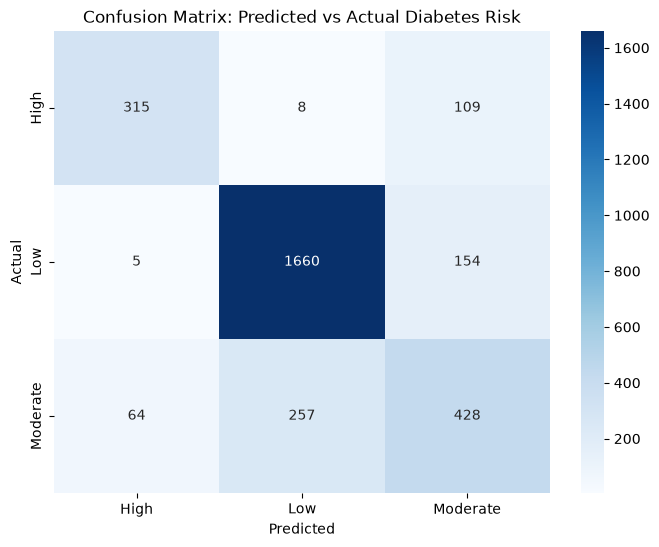

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create a confusion matrix to see exactly where the model made mistakes
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix: Predicted vs Actual Diabetes Risk')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()